In [53]:
import numpy as np
from numba import njit , prange
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from joblib import Parallel, delayed
from scipy.stats import skew
from scipy.ndimage import uniform_filter1d
from scipy.signal import hilbert
import pandas as pd
from tqdm import tqdm
import progressbar 
import os, json, time, gc, io, contextlib, math
from numba import set_num_threads, get_num_threads
from operator import mod
from itertools import product
from statsmodels.tsa.stattools import adfuller
from itertools import permutations
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm
import glob
import imageio.v2 as imageio
from scipy.integrate import solve_ivp
from math import comb
from scipy.interpolate import interp1d
from pathlib import Path
from loguru import logger
import typer
import sys
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

PROJ_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJ_ROOT))
REPORTS_DIR = PROJ_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

import moran.methods as methods
import moran.config as config
import moran.plots as plots

g=1

In [ ]:
def detect_events_ensemble(Mdot, Vdot, Sdot, skip, tmax, t_lag, n_individuals):
    """
    Detect events across an ensemble of signals.

    Parameters
    ----------
    Mdot, Vdot, Sdot : array, shape (n_ens, time)
    skip, tmax, t_lag, n_individuals : same as before

    Returns
    -------
    results : list of dicts (one per ensemble)
    """

    n_ens = Mdot.shape[0]
    results = []

    # time axis (same for all ensembles)
    tarray = np.arange(skip * n_individuals,
                       tmax * n_individuals,
                       t_lag) / n_individuals

    cutoff = int((tmax - skip) * n_individuals / t_lag)

    for k in range(n_ens):

        Md = Mdot[k]
        Vd = Vdot[k]
        Sd = Sdot[k]

        # --- smoothing ---
        M_s = gaussian_filter1d(Md[:cutoff], sigma=30)
        V_s = gaussian_filter1d(Vd[:cutoff], sigma=30)
        T_s = gaussian_filter1d(Sd[:cutoff], sigma=30)

        # --- peak detection ---
        M_peaks, _ = find_peaks(M_s, height=np.std(M_s), distance=100)
        T_peaks, _ = find_peaks(-T_s, height=np.std(T_s), distance=100)

        V_max_idx, _ = find_peaks(V_s, height=np.std(V_s), distance=100)
        V_min_idx, _ = find_peaks(-V_s, height=np.std(V_s), distance=100)

        extrema = np.sort(np.concatenate([V_max_idx, V_min_idx]))
        is_max = set(V_max_idx)
        is_min = set(V_min_idx)

        # --- zero crossings ---
        sign = np.sign(V_s)
        zc_idx = np.where(np.diff(sign))[0]

        # --- build cycles (peak → zero → trough) ---
        cycles = []
        i = 0
        while i < len(extrema) - 1:
            e1, e2 = extrema[i], extrema[i + 1]

            if not (e1 in is_max and e2 in is_min):
                i += 1
                continue

            z_candidates = zc_idx[(zc_idx > e1) & (zc_idx < e2)]
            if len(z_candidates) == 0:
                i += 1
                continue

            z = z_candidates[np.argmin(np.abs(z_candidates - (e1 + e2) / 2))]
            cycles.append((e1, z, e2))
            i += 2

        # unpack cycles
        V_peaks = np.array([c[0] for c in cycles])
        V_zeros = np.array([c[1] for c in cycles])
        V_troughs = np.array([c[2] for c in cycles])

        # --- event matching ---
        time_tol = 0.2
        events = []

        for mp in M_peaks:
            t_m = tarray[mp]

            # match T minimum
            t_candidates = T_peaks[np.abs(tarray[T_peaks] - t_m) < time_tol]
            if len(t_candidates) == 0:
                continue
            tp = t_candidates[np.argmin(np.abs(tarray[t_candidates] - t_m))]

            # match V zero crossing
            v_candidates = V_zeros[np.abs(tarray[V_zeros] - t_m) < time_tol]
            if len(v_candidates) == 0:
                continue
            vz = v_candidates[np.argmin(np.abs(tarray[v_candidates] - t_m))]

            # --- use cycle structure (FIXES NEGATIVE dt) ---
            cycle_idx = np.where(V_zeros == vz)[0]
            if len(cycle_idx) == 0:
                continue

            vpk, _, vtr = cycles[cycle_idx[0]]

            events.append({
                "t_event": t_m,
                "mp": mp,
                "tp": tp,
                "vz": vz,
                "vpk": vpk,
                "vtr": vtr,
                "M_peak": M_s[mp],
                "T_min": T_s[tp],
                "V_max": V_s[vpk],
                "V_min": V_s[vtr],
                "dt_M_T": tarray[tp] - t_m,
                "dt_M_V0": tarray[vz] - t_m,
                "dt_Vpk_Vtr": tarray[vtr] - tarray[vpk]
            })

        # --- convert to arrays ---
        event_times = np.array([e["t_event"] for e in events])
        waiting_times = np.diff(event_times) if len(event_times) > 1 else np.array([])

        res_k = {
            # time
            "event_times": event_times,
            "waiting_times": waiting_times,

            # indices
            "idx": {
                "M": np.array([e["mp"] for e in events]),
                "T": np.array([e["tp"] for e in events]),
                "V0": np.array([e["vz"] for e in events]),
                "Vpk": np.array([e["vpk"] for e in events]),
                "Vtr": np.array([e["vtr"] for e in events]),
            },

            # values
            "vals": {
                "M": np.array([e["M_peak"] for e in events]),
                "T": np.array([e["T_min"] for e in events]),
                "Vmax": np.array([e["V_max"] for e in events]),
                "Vmin": np.array([e["V_min"] for e in events]),
            },

            # time differences
            "dt": {
                "M_T": np.array([e["dt_M_T"] for e in events]),
                "M_V0": np.array([e["dt_M_V0"] for e in events]),
                "Vpk_Vtr": np.array([e["dt_Vpk_Vtr"] for e in events]),
            },

            # optional debug
            "raw_events": events
        }

        results.append(res_k)

        print(f"[ens {k}] events: {len(events)}, "
              f"mean wait: {np.mean(waiting_times) if len(waiting_times)>0 else np.nan:.3f}")

    return results

In [30]:
def detect_events_ensemble(Mdot, Vdot, Sdot, skip, tmax, t_lag, n_individuals):
    """
    Mdot, Vdot, Sdot: shape (n_ensemble, time)
    """

    n_ens = Mdot.shape[0]
    results = []

    for k in range(n_ens):
        Md = Mdot[k]
        Vd = Vdot[k]
        Sd = Sdot[k]

        tarray = np.arange(skip*n_individuals, tmax*n_individuals, t_lag) / n_individuals

        M_s = gaussian_filter1d(Md[:int((tmax-skip)*n_individuals/t_lag)], sigma=30)
        V_s = gaussian_filter1d(Vd[:int((tmax-skip)*n_individuals/t_lag)], sigma=30)
        T_s = gaussian_filter1d(Sd[:int((tmax-skip)*n_individuals/t_lag)], sigma=30)

        M_peaks, _ = find_peaks(M_s, height=np.std(M_s), distance=100)
        T_peaks, _ = find_peaks(-T_s, height=np.std(T_s), distance=100)

        V_max_idx, _ = find_peaks(V_s, height=np.std(V_s), distance=100)
        V_min_idx, _ = find_peaks(-V_s, height=np.std(V_s), distance=100)

        extrema = np.sort(np.concatenate([V_max_idx, V_min_idx]))
        is_max = set(V_max_idx)
        is_min = set(V_min_idx)

        sign = np.sign(V_s)
        zc_idx = np.where(np.diff(sign))[0]

        cycles = []
        i = 0
        while i < len(extrema) - 1:
            e1, e2 = extrema[i], extrema[i+1]

            if not (e1 in is_max and e2 in is_min):
                i += 1
                continue

            z_candidates = zc_idx[(zc_idx > e1) & (zc_idx < e2)]
            if len(z_candidates) == 0:
                i += 1
                continue

            z = z_candidates[np.argmin(np.abs(z_candidates - (e1+e2)/2))]
            cycles.append((e1, z, e2))
            i += 2

        V_peaks = np.array([c[0] for c in cycles])
        V_zeros = np.array([c[1] for c in cycles])
        V_troughs = np.array([c[2] for c in cycles])

        time_tol = 0.2
        events = []

        for mp in M_peaks:
            t_m = tarray[mp]

            t_candidates = T_peaks[np.abs(tarray[T_peaks] - t_m) < time_tol]
            if len(t_candidates) == 0:
                continue
            tp = t_candidates[np.argmin(np.abs(tarray[t_candidates] - t_m))]

            v_candidates = V_zeros[np.abs(tarray[V_zeros] - t_m) < time_tol]
            if len(v_candidates) == 0:
                continue
            vz = v_candidates[np.argmin(np.abs(tarray[v_candidates] - t_m))]

            vpk = V_peaks[np.argmin(np.abs(tarray[V_peaks] - t_m))]
            vtr = V_troughs[np.argmin(np.abs(tarray[V_troughs] - t_m))]

            events.append({
                "t_event": t_m,
                "mp": mp,
                "tp": tp,
                "vz": vz,
                "vpk": vpk,
                "vtr": vtr,
                "M_peak": M_s[mp],
                "T_min": T_s[tp],
                "V_max": V_s[vpk],
                "V_min": V_s[vtr],
                "dt_M_T": tarray[tp] - t_m,
                "dt_M_V0": tarray[vz] - t_m,
                "dt_Vpk_Vtr": tarray[vtr] - tarray[vpk]
            })

        # store per-ensemble result
        results.append({
            "events": events,
            "event_times": np.array([e["t_event"] for e in events]),
            "waiting_times": np.diff([e["t_event"] for e in events]) if len(events) > 1 else np.array([])
        })

    return results


In [52]:
def detect_events(Mdot, Vdot, Sdot, skip, tmax, t_lag, n_individuals):
    tarray = np.arange(skip*n_individuals, tmax*n_individuals, t_lag) / n_individuals
    M_s = gaussian_filter1d(Mdot[:int((tmax-skip)*n_individuals/t_lag)], sigma=30)
    V_s = gaussian_filter1d(Vdot[:int((tmax-skip)*n_individuals/t_lag)], sigma=30)
    T_s = gaussian_filter1d(Sdot[:int((tmax-skip)*n_individuals/t_lag)], sigma=30)

    M_peaks, _ = find_peaks( M_s, height=0*np.mean( M_s) + 0*np.std( M_s), distance=100)

    T_peaks, _ = find_peaks(-T_s, height=0*np.mean(-T_s) + 0*np.std(-T_s), distance=100)

    V_max_idx, _ = find_peaks(V_s, height=0*np.mean(V_s) + 0*np.std(V_s), distance=100)
    V_min_idx, _ = find_peaks(-V_s, height=0*np.mean(-V_s) + 0*np.std(-V_s), distance=100)
    extrema = np.sort(np.concatenate([V_max_idx, V_min_idx]))
    is_max = {i: True for i in V_max_idx}
    is_min = {i: True for i in V_min_idx}
    sign = np.sign(V_s)
    zc_idx = np.where(np.diff(sign))[0]
    cycles = []
    i = 0
    while i < len(extrema) - 1:
        e1 = extrema[i]
        e2 = extrema[i+1]
        if not (e1 in is_max and e2 in is_min):
            i += 1
            continue
        z_candidates = zc_idx[(zc_idx > e1) & (zc_idx < e2)]
        if len(z_candidates) == 0:
            i += 1
            continue
        mid = (e1 + e2) / 2
        z = z_candidates[np.argmin(np.abs(z_candidates - mid))]
        cycles.append((e1, z, e2))
        i += 2
    V_peaks = np.array([c[0] for c in cycles])
    V_zeros = np.array([c[1] for c in cycles])
    V_troughs = np.array([c[2] for c in cycles])


    time_tol = 0.2
    events = []
    event_M_idx = []
    event_T_idx = []
    event_V0_idx = []
    event_Vpk_idx = []
    event_Vtr_idx = []

    for e, mp in zip(events, M_peaks[:len(events)]): 
        pass

    for mp in M_peaks:
        t_m = tarray[mp]
        t_candidates = T_peaks[np.abs(tarray[T_peaks] - t_m) < time_tol]
        if len(t_candidates) == 0:
            continue
        tp = t_candidates[np.argmin(np.abs(tarray[t_candidates] - t_m))]
        v_candidates = V_zeros[np.abs(tarray[V_zeros] - t_m) < time_tol]
        if len(v_candidates) == 0:
            continue
        vz = v_candidates[np.argmin(np.abs(tarray[v_candidates] - t_m))]
        v_peak_near = V_peaks[np.argmin(np.abs(tarray[V_peaks] - t_m))]
        # v_trough_near = V_troughs[np.argmin(np.abs(tarray[V_troughs] - t_m))]
        v_trough_near = V_troughs[np.where(V_troughs > v_peak_near)[0][0]] if np.any(V_troughs > v_peak_near) else v_peak_near

        dt_M_T = tarray[tp] - t_m
        dt_M_V0 = tarray[vz] - t_m
        dt_Vpk_Vtr = tarray[v_trough_near] - tarray[v_peak_near]

        events.append({
            "mp": mp,
            "tp": tp,
            "vz": vz,
            "vpk": v_peak_near,
            "vtr": v_trough_near,
            "t_event": t_m,
            "M_peak": M_s[mp],
            "T_min": T_s[tp],
            "V_max": V_s[v_peak_near],
            "V_min": V_s[v_trough_near],
            "dt_M_T": dt_M_T,
            "dt_M_V0": dt_M_V0,
            "dt_Vpk_Vtr": dt_Vpk_Vtr
        })
    event_times = np.array([e["t_event"] for e in events])

    M_vals = np.array([e["M_peak"] for e in events])
    T_vals = np.array([e["T_min"] for e in events])
    V_max_vals = np.array([e["V_max"] for e in events])
    V_min_vals = np.array([e["V_min"] for e in events])

    dt_M_T = np.array([e["dt_M_T"] for e in events])
    dt_M_V0 = np.array([e["dt_M_V0"] for e in events])
    dt_Vpk_Vtr = np.array([e["dt_Vpk_Vtr"] for e in events])

    waiting_times = np.diff(event_times)

    print(f"Number of events: {len(events)}")
    print(f"Mean waiting time: {np.mean(waiting_times):.3f}")

    event_M_idx  = np.array([e["mp"]  for e in events])
    event_T_idx  = np.array([e["tp"]  for e in events])
    event_V0_idx = np.array([e["vz"]  for e in events])
    event_Vpk_idx = np.array([e["vpk"] for e in events])
    event_Vtr_idx = np.array([e["vtr"] for e in events])

    return tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times, M_vals, T_vals, V_max_vals, V_min_vals, dt_M_T, dt_M_V0, dt_Vpk_Vtr, waiting_times

def detect_events_ensemble(Mdot, Vdot, Sdot, skip, tmax, t_lag, n_individuals):
    n_ens = Mdot.shape[0]

    # aggregated outputs (same order as original return)
    outputs = [[] for _ in range(23)]  # your function returns 23 items

    for k in range(n_ens):
        res = detect_events(
            Mdot[k], Vdot[k], Sdot[k],
            skip, tmax, t_lag, n_individuals
        )

        for i, r in enumerate(res):
            outputs[i].append(r)

    # optional: convert what we safely can to arrays
    outputs[0] = outputs[0][0]  # tarray (same for all)
    # everything else stays list-of-arrays (since lengths differ)

    return tuple(outputs)

def plot_events(tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times):
    # ---- plotting ----
    fig, axs = plt.subplots(3, 1, figsize=(20, 10), sharex=True)

    # Mdot
    axs[0].plot(tarray, M_s, label="Mdot")
    axs[0].scatter(tarray[M_peaks], M_s[M_peaks], color="red", label="M peaks")

    # Vdot
    axs[1].plot(tarray, V_s, label="Vdot")
    axs[1].scatter(tarray[V_peaks], V_s[V_peaks], color="red", label="V peaks")
    axs[1].scatter(tarray[V_troughs], V_s[V_troughs], color="blue", label="V troughs")
    axs[1].scatter(tarray[V_zeros], V_s[V_zeros], color="green", label="V zeros")


    # Tdot
    axs[2].plot(tarray, T_s, label="Tdot")
    axs[2].scatter(tarray[T_peaks], T_s[T_peaks], color="purple", label="T minima")

    # ---- vertical lines for alignment ----
    # for ax in axs:
    #     for p in M_peaks:
    #         ax.axvline(tarray[p], color="red", linestyle="--", alpha=0.3)
    #     for p in T_peaks:
    #         ax.axvline(tarray[p], color="purple", linestyle="--", alpha=0.3)
        # for z in V_zeros:
        #     ax.axvline(tarray[z], color="green", linestyle=":", alpha=0.2)



    for ax in axs:
        for t in event_times:
            ax.axvline(t, color="red", linestyle="--", alpha=0.3)



    # Mdot (highlight matched ones)
    axs[0].scatter(tarray[event_M_idx], M_s[event_M_idx],
                s=120, facecolors='none', edgecolors='black',
                linewidths=2, label="Matched M peaks")

    # Vdot
    axs[1].scatter(tarray[event_Vpk_idx], V_s[event_Vpk_idx],
                s=120, facecolors='none', edgecolors='black', linewidths=2,
                label="Matched V peaks")

    axs[1].scatter(tarray[event_Vtr_idx], V_s[event_Vtr_idx],
                s=120, facecolors='none', edgecolors='cyan', linewidths=2,
                label="Matched V troughs")

    axs[1].scatter(tarray[event_V0_idx], V_s[event_V0_idx],
                s=120, facecolors='none', edgecolors='lime', linewidths=2,
                label="Matched V zeros")

    # Tdot
    axs[2].scatter(tarray[event_T_idx], T_s[event_T_idx],
                s=120, facecolors='none', edgecolors='black',
                linewidths=2, label="Matched T minima")






    # labels
    axs[0].set_ylabel("Mdot")
    axs[1].set_ylabel("Vdot")
    axs[2].set_ylabel("Tdot")
    axs[2].set_xlabel("Time")

    for ax in axs:
        ax.legend()

    plt.tight_layout()
    plt.show()



In [23]:
def detect_events_ensemble(Mdot, Vdot, Sdot, skip, tmax, t_lag, n_individuals):
    n_ens = Mdot.shape[0]

    # Time axis (same for all ensembles)
    tarray = np.arange(skip*n_individuals, tmax*n_individuals, t_lag) / n_individuals

    # Storage
    M_s_all, V_s_all, T_s_all = [], [], []
    M_peaks_all, T_peaks_all = [], []
    V_peaks_all, V_zeros_all, V_troughs_all = [], [], []

    event_M_idx_all, event_T_idx_all = [], []
    event_V0_idx_all, event_Vpk_idx_all, event_Vtr_idx_all = [], [], []

    event_times_all = []
    M_vals_all, T_vals_all = [], []
    V_max_vals_all, V_min_vals_all = [], []

    dt_M_T_all, dt_M_V0_all, dt_Vpk_Vtr_all = [], [], []
    waiting_times_all = []

    for k in range(n_ens):
        Mdot_k = Mdot[k]
        Vdot_k = Vdot[k]
        Sdot_k = Sdot[k]

        # --- smoothing ---
        cutoff = int((tmax - skip) * n_individuals / t_lag)
        M_s = gaussian_filter1d(Mdot_k[:cutoff], sigma=30)
        V_s = gaussian_filter1d(Vdot_k[:cutoff], sigma=30)
        T_s = gaussian_filter1d(Sdot_k[:cutoff], sigma=30)

        # --- peaks ---
        M_peaks, _ = find_peaks(M_s, height=np.std(M_s), distance=100)
        T_peaks, _ = find_peaks(-T_s, height=np.std(-T_s), distance=100)

        V_max_idx, _ = find_peaks(V_s, height=np.std(V_s), distance=100)
        V_min_idx, _ = find_peaks(-V_s, height=np.std(-V_s), distance=100)

        extrema = np.sort(np.concatenate([V_max_idx, V_min_idx]))
        is_max = set(V_max_idx)
        is_min = set(V_min_idx)

        sign = np.sign(V_s)
        zc_idx = np.where(np.diff(sign))[0]

        # --- cycles ---
        cycles = []
        i = 0
        while i < len(extrema) - 1:
            e1, e2 = extrema[i], extrema[i+1]

            if not (e1 in is_max and e2 in is_min):
                i += 1
                continue

            z_candidates = zc_idx[(zc_idx > e1) & (zc_idx < e2)]
            if len(z_candidates) == 0:
                i += 1
                continue

            mid = (e1 + e2) / 2
            z = z_candidates[np.argmin(np.abs(z_candidates - mid))]

            cycles.append((e1, z, e2))
            i += 2

        V_peaks = np.array([c[0] for c in cycles])
        V_zeros = np.array([c[1] for c in cycles])
        V_troughs = np.array([c[2] for c in cycles])

        # --- event matching ---
        time_tol = 0.2
        events = []

        for mp in M_peaks:
            t_m = tarray[mp]

            t_candidates = T_peaks[np.abs(tarray[T_peaks] - t_m) < time_tol]
            if len(t_candidates) == 0:
                continue
            tp = t_candidates[np.argmin(np.abs(tarray[t_candidates] - t_m))]

            v_candidates = V_zeros[np.abs(tarray[V_zeros] - t_m) < time_tol]
            if len(v_candidates) == 0:
                continue
            vz = v_candidates[np.argmin(np.abs(tarray[v_candidates] - t_m))]

            if len(V_peaks) == 0 or len(V_troughs) == 0:
                continue

            vpk = V_peaks[np.argmin(np.abs(tarray[V_peaks] - t_m))]
            vtr = V_troughs[np.argmin(np.abs(tarray[V_troughs] - t_m))]

            events.append({
                "mp": mp,
                "tp": tp,
                "vz": vz,
                "vpk": vpk,
                "vtr": vtr,
                "t_event": t_m,
                "M_peak": M_s[mp],
                "T_min": T_s[tp],
                "V_max": V_s[vpk],
                "V_min": V_s[vtr],
                "dt_M_T": tarray[tp] - t_m,
                "dt_M_V0": tarray[vz] - t_m,
                "dt_Vpk_Vtr": tarray[vtr] - tarray[vpk]
            })

        # --- convert ---
        event_times = np.array([e["t_event"] for e in events])
        waiting_times = np.diff(event_times) if len(event_times) > 1 else np.array([])

        # --- store ---
        M_s_all.append(M_s)
        V_s_all.append(V_s)
        T_s_all.append(T_s)

        M_peaks_all.append(M_peaks)
        T_peaks_all.append(T_peaks)

        V_peaks_all.append(V_peaks)
        V_zeros_all.append(V_zeros)
        V_troughs_all.append(V_troughs)

        event_M_idx_all.append(np.array([e["mp"] for e in events]))
        event_T_idx_all.append(np.array([e["tp"] for e in events]))
        event_V0_idx_all.append(np.array([e["vz"] for e in events]))
        event_Vpk_idx_all.append(np.array([e["vpk"] for e in events]))
        event_Vtr_idx_all.append(np.array([e["vtr"] for e in events]))

        event_times_all.append(event_times)
        M_vals_all.append(np.array([e["M_peak"] for e in events]))
        T_vals_all.append(np.array([e["T_min"] for e in events]))
        V_max_vals_all.append(np.array([e["V_max"] for e in events]))
        V_min_vals_all.append(np.array([e["V_min"] for e in events]))

        dt_M_T_all.append(np.array([e["dt_M_T"] for e in events]))
        dt_M_V0_all.append(np.array([e["dt_M_V0"] for e in events]))
        dt_Vpk_Vtr_all.append(np.array([e["dt_Vpk_Vtr"] for e in events]))

        waiting_times_all.append(waiting_times)

        print(f"[ens {k}] events: {len(events)}, mean wait: {np.mean(waiting_times) if len(waiting_times)>0 else np.nan:.3f}")

    return {
        "tarray": tarray,
        "M_s": M_s_all,
        "V_s": V_s_all,
        "T_s": T_s_all,
        "M_peaks": M_peaks_all,
        "T_peaks": T_peaks_all,
        "V_peaks": V_peaks_all,
        "V_zeros": V_zeros_all,
        "V_troughs": V_troughs_all,
        "event_M_idx": event_M_idx_all,
        "event_T_idx": event_T_idx_all,
        "event_V0_idx": event_V0_idx_all,
        "event_Vpk_idx": event_Vpk_idx_all,
        "event_Vtr_idx": event_Vtr_idx_all,
        "event_times": event_times_all,
        "M_vals": M_vals_all,
        "T_vals": T_vals_all,
        "V_max_vals": V_max_vals_all,
        "V_min_vals": V_min_vals_all,
        "dt_M_T": dt_M_T_all,
        "dt_M_V0": dt_M_V0_all,
        "dt_Vpk_Vtr": dt_Vpk_Vtr_all,
        "waiting_times": waiting_times_all
    }


def aggregate_global(results):
    def concat(key):
        return np.concatenate([arr for arr in results[key] if len(arr) > 0])

    stats = {}

    stats["waiting_times"] = concat("waiting_times")
    stats["dt_M_T"] = concat("dt_M_T")
    stats["dt_M_V0"] = concat("dt_M_V0")
    stats["dt_Vpk_Vtr"] = concat("dt_Vpk_Vtr")

    stats["M_vals"] = concat("M_vals")
    stats["T_vals"] = concat("T_vals")
    stats["V_max_vals"] = concat("V_max_vals")
    stats["V_min_vals"] = concat("V_min_vals")

    # summary numbers
    summary = {
        "mean_waiting_time": np.mean(stats["waiting_times"]),
        "std_waiting_time": np.std(stats["waiting_times"]),
        "mean_dt_M_T": np.mean(stats["dt_M_T"]),
        "mean_dt_M_V0": np.mean(stats["dt_M_V0"]),
        "mean_dt_Vpk_Vtr": np.mean(stats["dt_Vpk_Vtr"]),
        "n_total_events": len(stats["M_vals"])
    }

    return stats, summary




In [54]:
def Plot_Moment_dynamics_simple( n_individuals, indices, Mdot, Vdot, Tdot, fig_dir, ex_name, figsize=(25, 15), dpi=600):
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True, constrained_layout=True)
    ax0 = axes[0]
    ax0.plot(indices/n_individuals, Mdot, label="M dot")
    ax0.set_ylabel(r"$\dot M$", fontsize=18)
    ax0.legend(fontsize=18)
    ax1 = axes[1]
    ax1.plot(indices/n_individuals, Vdot, label="V dot")
    ax1.set_ylabel(r"$\dot V$", fontsize=18)
    ax1.legend(fontsize=18)
    ax2 = axes[2]
    ax2.plot(indices/n_individuals, Tdot, label="T dot")
    ax2.set_xlabel("Time", fontsize=18)
    ax2.set_ylabel(r"$\dot T$", fontsize=18)
    ax2.legend(fontsize=18)

    fig.savefig(os.path.join(fig_dir, ex_name, f"moment_dynamics.png"), dpi=dpi, bbox_inches="tight")
    plt.close(fig)

In [71]:
def simulate_system(pR0, vL0, vR0, delta, g, bpd, dt=1e-2):

    pL0 = 1 - pR0
    muL = -pR0 * delta
    muR = pL0 * delta
    deltamu = muR - muL
    AA = bpd * deltamu
    BB = bpd**2 * (vR0-vL0)
    if BB == 0:
        tmax = np.log(-999*(1-1/pR0))/AA
    else:
        tmax = 1/(2*BB) * (-2*AA + np.sqrt(4*AA**2 + 8*BB*np.log(-999*(1-1/pR0))))
    max_steps = int(tmax / dt) + 1

    pR = pR0
    vL = vL0
    vR = vR0

    # storage
    t = 0.0
    V_vals = []
    t_vals = []

    # helper
    def compute_V(pR, muL, muR, vL, vR):
        pL = 1 - pR
        pRdot = bpd * pR * (1 - pR) * (muR - muL)
        muRdot = bpd * vR
        muLdot = bpd * vL
        vRdot = g**2
        vLdot = g**2
        V = ((1-pR) * vL + pR * vR + pR*(1-pR) * (muL-muR)**2)
        return V

    # ---- integration loop (RK4) ----
    for step in range(max_steps):

        # record
        V = compute_V(pR, muL, muR, vL, vR)
        V_vals.append(V)
        t_vals.append(t)

        # RK4
        def f(state):
            pR, muL, muR, vL, vR = state
            pRdot = bpd * pR * (1 - pR) * (muR - muL)
            muRdot = bpd * vR
            muLdot = bpd * vL
            vRdot = g**2
            vLdot = g**2
            return np.array([pRdot, muLdot, muRdot, vLdot, vRdot])

        y = np.array([pR, muL, muR, vL, vR])

        k1 = f(y)
        k2 = f(y + 0.5 * dt * k1)
        k3 = f(y + 0.5 * dt * k2)
        k4 = f(y + dt * k3)

        y = y + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

        pR, muL, muR, vL, vR = y
        t += dt

    # ---- convert to arrays ----
    t_vals = np.array(t_vals)
    V_vals = np.array(V_vals)
    Vdot_vals = np.gradient(V_vals, t_vals)

    # ---- feature extraction ----
    if len(Vdot_vals) < 10:
        return None

    vmax_idx = np.argmax(Vdot_vals)
    vmin_idx = np.argmin(Vdot_vals)

    VdotMax = Vdot_vals[vmax_idx]
    VdotMin = Vdot_vals[vmin_idx]

    tPeak = t_vals[vmax_idx]
    tMin = t_vals[vmin_idx]

    # zero crossing
    sign_change = np.where(np.diff(np.sign(Vdot_vals)))[0]
    tZero = t_vals[sign_change[0]] if len(sign_change) > 0 else np.nan

    return {
        "pR0": pR0,
        "vL0": vL0,
        "vR0": vR0,
        "delta": delta,
        "g": g,
        "bpd": bpd,
        "VdotMax": VdotMax,
        "VdotMin": VdotMin,
        "tPeak": tPeak,
        "tMin": tMin,
        "tZero": tZero,
        "Deltat1": abs(tPeak - tZero),
        "Deltat2": abs(tMin - tZero),
        "DeltaT": abs(tPeak - tMin)
    }


def run_parameter_sweep(pR_list, vL_list, vR_list, delta_list, g_list, bpd_list, save_path, n_jobs=8):
    combinations = list(product(pR_list, vL_list, vR_list, delta_list, g_list, bpd_list))
    def process_one(params):
        pR0, vL0, vR0, delta, g, bpd = params

        try:
            res = simulate_system(
                pR0, vL0, vR0, delta, g, bpd
            )
            return res
        except:
            return None

    results = Parallel(n_jobs=n_jobs, backend="loky")( delayed(process_one)(params) for params in tqdm(combinations, desc="Simulating") )

    # remove failed
    results = [r for r in results if r is not None]

    df = pd.DataFrame(results)

    filename = "results.csv"
    file_path = os.path.join(save_path, filename)
    df.to_csv(file_path, index=False)
    print(f"✅ Saved to {save_path}")

    return df

pR_list = np.arange(0.01, 0.15, 0.01)
vL_list = np.array([3])
vR_list = np.arange(1, 5, 0.2)
delta_list = np.arange(10, 15, 0.1)
g_list = np.array([1])
bpd_list = np.array([1])

save_dir=REPORTS_DIR / f"detection_PR({pR_list[0]},{pR_list[-1]})_bpd({bpd_list[0]},{bpd_list[-1]})_delta({delta_list[0]},{delta_list[-1]})_g({g_list[0]},{g_list[-1]})_VR({vR_list[0]},{vR_list[-1]})"
os.makedirs(save_dir, exist_ok=True)
df = run_parameter_sweep(pR_list, vL_list, vR_list, delta_list, g_list, bpd_list, save_dir, n_jobs=6)


Simulating: 100%|██████████| 14000/14000 [00:12<00:00, 1127.62it/s]


✅ Saved to C:\Users\ah741\Desktop\fitness_waves\reports\detection_PR(0.01,0.14)_bpd(1,1)_delta(10.0,14.899999999999983)_g(1,1)_VR(1.0,4.799999999999999)


In [4]:
pR_list = np.arange(0.01, 0.15, 0.01)
vL_list = np.array([3])
vR_list = np.arange(1, 5, 0.2)
delta_list = np.arange(10, 15, 0.1)
g_list = np.array([1])
bpd_list = np.array([1])

save_dir=REPORTS_DIR / f"detection_PR({pR_list[0]},{pR_list[-1]})_bpd({bpd_list[0]},{bpd_list[-1]})_delta({delta_list[0]},{delta_list[-1]})_g({g_list[0]},{g_list[-1]})_VR({vR_list[0]},{vR_list[-1]})"
df = pd.read_csv(save_dir / "results.csv")

In [5]:
df["deltav"] = df["vR0"] - df["vL0"]
df

,pR0,vL0,vR0,delta,g,bpd,VdotMax,VdotMin,tPeak,tMin,tZero,Deltat1,Deltat2,DeltaT,deltav
0,0.01,3,1.0,10.0,1,1,70.230379,-72.554461,0.32,0.61,0.46,0.14,0.15,0.29,-2.0
1,0.01,3,1.0,10.1,1,1,72.863124,-75.252187,0.32,0.61,0.46,0.14,0.15,0.29,-2.0
2,0.01,3,1.0,10.2,1,1,75.498767,-77.965413,0.32,0.60,0.45,0.13,0.15,0.28,-2.0
3,0.01,3,1.0,10.3,1,1,78.166946,-80.665759,0.31,0.60,0.45,0.14,0.15,0.29,-2.0
4,0.01,3,1.0,10.4,1,1,81.001880,-83.566285,0.31,0.59,0.44,0.13,0.15,0.28,-2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13334,0.14,3,4.8,14.5,1,1,310.272526,-301.819146,0.04,0.22,0.12,0.08,0.10,0.18,1.8
13335,0.14,3,4.8,14.6,1,1,316.393755,-307.568979,0.04,0.22,0.12,0.08,0.10,0.18,1.8
13336,0.14,3,4.8,14.7,1,1,322.588481,-313.978460,0.04,0.21,0.12,0.08,0.09,0.17,1.8
13337,0.14,3,4.8,14.8,1,1,328.856801,-320.612540,0.04,0.21,0.12,0.08,0.09,0.17,1.8


In [6]:
X = df[["pR0","deltav","delta"]]
yvmax = df["VdotMax"]
yvmin = df["VdotMin"]
ytpeak = df["DeltaT"]

modelvmax = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
modelvmax.fit(X, yvmax)
print("R^2:", modelvmax.score(X, yvmax))

modelvmin = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
modelvmin.fit(X, yvmin)
print("R^2:", modelvmin.score(X, yvmin))

modeltpeak = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
modeltpeak.fit(X, ytpeak)
print("R^2:", modeltpeak.score(X, ytpeak))

R^2: 0.9997010945308694
R^2: 0.9996938705502953
R^2: 0.9747277913265556


In [ ]:
Xtest = np.array([[0.01, -2, 10]])
Xtest = np.array([[0.14, 1.8, 14.9]])
print("Predicted VdotMax:", modelvmax.predict(Xtest))
print("Predicted VdotMin:", modelvmin.predict(Xtest))
print("Predicted DeltaT:", modeltpeak.predict(Xtest))

Predicted VdotMax: [334.39606277]
Predicted VdotMin: [-325.80719926]
Predicted DeltaT: [0.17880823]


C:\Users\ah741\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\ah741\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\ah741\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [7]:
poly = modelvmax.named_steps["polynomialfeatures"]
lin = modelvmax.named_steps["linearregression"]
feature_names = poly.get_feature_names_out(X.columns)
coefs = lin.coef_
intercept = lin.intercept_
terms = []
for name, coef in zip(feature_names, coefs):
    if abs(coef) > 1e-6:   # ignore tiny terms
        terms.append(f"{coef:.4g}*{name}")
formula = " + ".join(terms)
print("VdotMax ≈")
print(f"{intercept:.4g} + " + formula)
#####################################################
poly = modelvmin.named_steps["polynomialfeatures"]
lin = modelvmin.named_steps["linearregression"]
feature_names = poly.get_feature_names_out(X.columns)
coefs = lin.coef_
intercept = lin.intercept_
terms = []
for name, coef in zip(feature_names, coefs):
    if abs(coef) > 1e-6:   # ignore tiny terms
        terms.append(f"{coef:.4g}*{name}")
formula = " + ".join(terms)
print("VdotMin ≈")
print(f"{intercept:.4g} + " + formula)
#####################################################
poly = modeltpeak.named_steps["polynomialfeatures"]
lin = modeltpeak.named_steps["linearregression"]
feature_names = poly.get_feature_names_out(X.columns)
coefs = lin.coef_
intercept = lin.intercept_
terms = []
for name, coef in zip(feature_names, coefs):
    if abs(coef) > 1e-6:   # ignore tiny terms
        terms.append(f"{coef:.4g}*{name}")
formula = " + ".join(terms)
print("DeltaT ≈")
print(f"{intercept:.4g} + " + formula)

VdotMax ≈
179.9 + -5.756*pR0 + 4.941*deltav + -43.78*delta + -36.09*pR0^2 + -65.81*pR0 deltav + 0.7352*pR0 delta + 0.2281*deltav^2 + 0.9018*deltav delta + 3.556*delta^2
VdotMin ≈
-177.7 + 4.405*pR0 + -4.971*deltav + 43.75*delta + 38.32*pR0^2 + 65.87*pR0 deltav + -0.6956*pR0 delta + -0.1749*deltav^2 + -0.66*deltav delta + -3.556*delta^2
DeltaT ≈
0.6484 + -0.04053*pR0 + -0.01823*deltav + -0.05242*delta + 0.0688*pR0^2 + 0.02789*pR0 deltav + 0.002286*pR0 delta + 5.497e-05*deltav^2 + 0.0009719*deltav delta + 0.001399*delta^2


In [13]:
pR_list = np.arange(0.01, 0.2, 0.01)
vL_list = np.array([3])
vR_list = np.arange(1, 5, 0.2)
delta_list = np.arange(10, 15, 0.1)
g_list = np.arange(1, 5, 0.5)
bpd_list = np.arange(0.1, 2, 0.1)

save_dir=REPORTS_DIR / f"detection_PR({pR_list[0]},{pR_list[-1]})_bpd({bpd_list[0]},{bpd_list[-1]})_delta({delta_list[0]},{delta_list[-1]})_g({g_list[0]},{g_list[-1]})_VR({vR_list[0]},{vR_list[-1]})"
df = pd.read_csv(save_dir / "results.csv")

In [14]:
df

,pR0,vL0,vR0,delta,g,bpd,VdotMax,VdotMin,tPeak,tMin,tZero,Deltat1,Deltat2,DeltaT
0,0.01,3,1.0,10.0,1.0,0.1,7.936153,-6.371227,3.24,6.14,4.78,1.54,1.36,2.90
1,0.01,3,1.0,10.0,1.0,0.2,14.871721,-13.741859,1.62,3.07,2.36,0.74,0.71,1.45
2,0.01,3,1.0,10.0,1.0,0.3,21.806120,-21.111005,1.08,2.05,1.56,0.48,0.49,0.97
3,0.01,3,1.0,10.0,1.0,0.4,28.738766,-28.475873,0.81,1.54,1.17,0.36,0.37,0.73
4,0.01,3,1.0,10.0,1.0,0.5,35.666570,-35.843830,0.65,1.23,0.93,0.28,0.30,0.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2750787,0.19,3,4.8,14.9,4.5,1.5,517.815916,-462.514171,0.00,0.13,0.06,0.06,0.07,0.13
2750788,0.19,3,4.8,14.9,4.5,1.6,551.084173,-496.156094,0.00,0.12,0.06,0.06,0.06,0.12
2750789,0.19,3,4.8,14.9,4.5,1.7,584.321914,-528.930342,0.00,0.11,0.05,0.05,0.06,0.11
2750790,0.19,3,4.8,14.9,4.5,1.8,617.521018,-556.415824,0.00,0.10,0.05,0.05,0.05,0.10


In [ ]:
def simulate_system(pR0, vL0, vR0, delta, g, bpd, dt=1e-2):

    pL0 = 1 - pR0
    muL = -pR0 * delta
    muR = pL0 * delta
    deltamu = muR - muL
    AA = bpd * deltamu
    BB = bpd**2 * (vR0-vL0)
    if BB == 0:
        tmax = np.log(-999*(1-1/pR0))/AA
    else:
        tmax = 1/(2*BB) * (-2*AA + np.sqrt(4*AA**2 + 8*BB*np.log(-999*(1-1/pR0))))
    max_steps = int(tmax / dt) + 1

    pR = pR0
    vL = vL0
    vR = vR0

    # storage
    t = 0.0
    V_vals = []
    t_vals = []

    # helper
    def compute_V(pR, muL, muR, vL, vR):
        pL = 1 - pR
        pRdot = bpd * pR * (1 - pR) * (muR - muL)
        muRdot = bpd * vR
        muLdot = bpd * vL
        vRdot = g**2
        vLdot = g**2
        V = ((1-pR) * vL + pR * vR + pR*(1-pR) * (muL-muR)**2)
        return V

    # ---- integration loop (RK4) ----
    for step in range(max_steps):

        # record
        V = compute_V(pR, muL, muR, vL, vR)
        V_vals.append(V)
        t_vals.append(t)

        # RK4
        def f(state):
            pR, muL, muR, vL, vR = state
            pRdot = bpd * pR * (1 - pR) * (muR - muL)
            muRdot = bpd * vR
            muLdot = bpd * vL
            vRdot = g**2
            vLdot = g**2
            return np.array([pRdot, muLdot, muRdot, vLdot, vRdot])

        y = np.array([pR, muL, muR, vL, vR])

        k1 = f(y)
        k2 = f(y + 0.5 * dt * k1)
        k3 = f(y + 0.5 * dt * k2)
        k4 = f(y + dt * k3)

        y = y + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

        pR, muL, muR, vL, vR = y
        t += dt

    # ---- convert to arrays ----
    t_vals = np.array(t_vals)
    V_vals = np.array(V_vals)
    Vdot_vals = np.gradient(V_vals, t_vals)

    # ---- feature extraction ----
    if len(Vdot_vals) < 10:
        return None

    vmax_idx = np.argmax(Vdot_vals)
    vmin_idx = np.argmin(Vdot_vals)

    VdotMax = Vdot_vals[vmax_idx]
    VdotMin = Vdot_vals[vmin_idx]

    tPeak = t_vals[vmax_idx]
    tMin = t_vals[vmin_idx]

    # zero crossing
    sign_change = np.where(np.diff(np.sign(Vdot_vals)))[0]
    tZero = t_vals[sign_change[0]] if len(sign_change) > 0 else np.nan

    return {
        "pR0": pR0,
        "vL0": vL0,
        "vR0": vR0,
        "delta": delta,
        "g": g,
        "bpd": bpd,
        "VdotMax": VdotMax,
        "VdotMin": VdotMin,
        "tPeak": tPeak,
        "tMin": tMin,
        "tZero": tZero,
        "Deltat1": abs(tPeak - tZero),
        "Deltat2": abs(tMin - tZero),
        "DeltaT": abs(tPeak - tMin)
    }


def run_parameter_sweep(pR_list, vL_list, vR_list, delta_list, g_list, bpd_list, save_path, n_jobs=8):
    combinations = list(product(pR_list, vL_list, vR_list, delta_list, g_list, bpd_list))
    def process_one(params):
        pR0, vL0, vR0, delta, g, bpd = params

        try:
            res = simulate_system(
                pR0, vL0, vR0, delta, g, bpd
            )
            return res
        except:
            return None

    results = Parallel(n_jobs=n_jobs, backend="loky")( delayed(process_one)(params) for params in tqdm(combinations, desc="Simulating") )

    # remove failed
    results = [r for r in results if r is not None]

    df = pd.DataFrame(results)

    filename = "results.csv"
    file_path = os.path.join(save_path, filename)
    df.to_csv(file_path, index=False)
    print(f"✅ Saved to {save_path}")

    return df

@njit
def simulate_system_numba(pR0, vL0, vR0, delta, g, bpd, dt=1e-2):

    pL0 = 1.0 - pR0
    muL = -pR0 * delta
    muR = pL0 * delta

    deltamu = muR - muL
    AA = bpd * deltamu
    BB = bpd**2 * (vR0 - vL0)

    val = -999.0 * (1.0 - 1.0/pR0)

    if BB == 0.0:
        tmax = np.log(val) / AA
    else:
        tmax = ( -2.0*AA + np.sqrt(4.0*AA**2 + 8.0*BB*np.log(val)) ) / (2.0*BB)

    max_steps = int(tmax / dt) + 1

    # state variables
    pR = pR0
    vL = vL0
    vR = vR0

    # preallocate
    t_vals = np.zeros(max_steps)
    V_vals = np.zeros(max_steps)

    t = 0.0

    # ---- integration ----
    for i in range(max_steps):

        # compute V
        pL = 1.0 - pR
        V = pL * vL + pR * vR + pR * pL * (muL - muR)**2

        t_vals[i] = t
        V_vals[i] = V

        # RK4 inline
        # k1
        pRdot = bpd * pR * (1.0 - pR) * (muR - muL)
        muRdot = bpd * vR
        muLdot = bpd * vL
        vRdot = g*g
        vLdot = g*g

        k1_pR = pRdot
        k1_muL = muLdot
        k1_muR = muRdot
        k1_vL = vLdot
        k1_vR = vRdot

        # k2
        pR2 = pR + 0.5*dt*k1_pR
        muL2 = muL + 0.5*dt*k1_muL
        muR2 = muR + 0.5*dt*k1_muR
        vL2 = vL + 0.5*dt*k1_vL
        vR2 = vR + 0.5*dt*k1_vR

        k2_pR = bpd * pR2 * (1.0 - pR2) * (muR2 - muL2)
        k2_muL = bpd * vL2
        k2_muR = bpd * vR2
        k2_vL = g*g
        k2_vR = g*g

        # k3
        pR3 = pR + 0.5*dt*k2_pR
        muL3 = muL + 0.5*dt*k2_muL
        muR3 = muR + 0.5*dt*k2_muR
        vL3 = vL + 0.5*dt*k2_vL
        vR3 = vR + 0.5*dt*k2_vR

        k3_pR = bpd * pR3 * (1.0 - pR3) * (muR3 - muL3)
        k3_muL = bpd * vL3
        k3_muR = bpd * vR3
        k3_vL = g*g
        k3_vR = g*g

        # k4
        pR4 = pR + dt*k3_pR
        muL4 = muL + dt*k3_muL
        muR4 = muR + dt*k3_muR
        vL4 = vL + dt*k3_vL
        vR4 = vR + dt*k3_vR

        k4_pR = bpd * pR4 * (1.0 - pR4) * (muR4 - muL4)
        k4_muL = bpd * vL4
        k4_muR = bpd * vR4
        k4_vL = g*g
        k4_vR = g*g

        # update
        pR += (dt/6.0)*(k1_pR + 2*k2_pR + 2*k3_pR + k4_pR)
        muL += (dt/6.0)*(k1_muL + 2*k2_muL + 2*k3_muL + k4_muL)
        muR += (dt/6.0)*(k1_muR + 2*k2_muR + 2*k3_muR + k4_muR)
        vL += (dt/6.0)*(k1_vL + 2*k2_vL + 2*k3_vL + k4_vL)
        vR += (dt/6.0)*(k1_vR + 2*k2_vR + 2*k3_vR + k4_vR)

        t += dt

    # ---- compute Vdot manually ----
    n = max_steps
    Vdot = np.zeros(n)

    for i in range(1, n-1):
        Vdot[i] = (V_vals[i+1] - V_vals[i-1]) / (t_vals[i+1] - t_vals[i-1])

    Vdot[0] = Vdot[1]
    Vdot[n-1] = Vdot[n-2]

    # ---- features ----
    vmax_idx = np.argmax(Vdot)
    vmin_idx = np.argmin(Vdot)

    VdotMax = Vdot[vmax_idx]
    VdotMin = Vdot[vmin_idx]

    tPeak = t_vals[vmax_idx]
    tMin = t_vals[vmin_idx]

    # zero crossing
    tZero = np.nan
    for i in range(n-1):
        if Vdot[i] * Vdot[i+1] < 0.0:
            tZero = t_vals[i]
            break

    # return fixed array
    return np.array([
        pR0, vL0, vR0, delta, g, bpd,
        VdotMax, VdotMin,
        tPeak, tMin, tZero,
        abs(tPeak - tZero),
        abs(tMin - tZero),
        abs(tPeak - tMin)
    ])


@njit
def simulate_system_numba(pR0, vL0, vR0, delta, g, bpd, dt):

    pL0 = 1.0 - pR0
    muL = -pR0 * delta
    muR = pL0 * delta

    deltamu = muR - muL
    AA = bpd * deltamu
    BB = bpd**2 * (vR0 - vL0)

    val = -999.0 * (1.0 - 1.0/pR0)

    if BB == 0.0:
        tmax = np.log(val) / AA
    else:
        tmax = (-2.0*AA + np.sqrt(4.0*AA**2 + 8.0*BB*np.log(val))) / (2.0*BB)

    max_steps = int(tmax / dt) + 1

    # state
    pR = pR0
    vL = vL0
    vR = vR0

    t_vals = np.zeros(max_steps)
    V_vals = np.zeros(max_steps)

    t = 0.0

    for i in range(max_steps):

        pL = 1.0 - pR
        V_vals[i] = pL*vL + pR*vR + pR*pL*(muL - muR)**2
        t_vals[i] = t

        # RK4 (inline)
        # k1
        k1_pR = bpd * pR * (1.0 - pR) * (muR - muL)
        k1_muL = bpd * vL
        k1_muR = bpd * vR
        k1_vL = g*g
        k1_vR = g*g

        # k2
        pR2 = pR + 0.5*dt*k1_pR
        muL2 = muL + 0.5*dt*k1_muL
        muR2 = muR + 0.5*dt*k1_muR
        vL2 = vL + 0.5*dt*k1_vL
        vR2 = vR + 0.5*dt*k1_vR

        k2_pR = bpd * pR2 * (1.0 - pR2) * (muR2 - muL2)
        k2_muL = bpd * vL2
        k2_muR = bpd * vR2
        k2_vL = g*g
        k2_vR = g*g

        # k3
        pR3 = pR + 0.5*dt*k2_pR
        muL3 = muL + 0.5*dt*k2_muL
        muR3 = muR + 0.5*dt*k2_muR
        vL3 = vL + 0.5*dt*k2_vL
        vR3 = vR + 0.5*dt*k2_vR

        k3_pR = bpd * pR3 * (1.0 - pR3) * (muR3 - muL3)
        k3_muL = bpd * vL3
        k3_muR = bpd * vR3
        k3_vL = g*g
        k3_vR = g*g

        # k4
        pR4 = pR + dt*k3_pR
        muL4 = muL + dt*k3_muL
        muR4 = muR + dt*k3_muR
        vL4 = vL + dt*k3_vL
        vR4 = vR + dt*k3_vR

        k4_pR = bpd * pR4 * (1.0 - pR4) * (muR4 - muL4)
        k4_muL = bpd * vL4
        k4_muR = bpd * vR4
        k4_vL = g*g
        k4_vR = g*g

        # update
        pR += (dt/6.0)*(k1_pR + 2*k2_pR + 2*k3_pR + k4_pR)
        muL += (dt/6.0)*(k1_muL + 2*k2_muL + 2*k3_muL + k4_muL)
        muR += (dt/6.0)*(k1_muR + 2*k2_muR + 2*k3_muR + k4_muR)
        vL += (dt/6.0)*(k1_vL + 2*k2_vL + 2*k3_vL + k4_vL)
        vR += (dt/6.0)*(k1_vR + 2*k2_vR + 2*k3_vR + k4_vR)

        t += dt

    # ---- Vdot ----
    n = max_steps
    if n < 3:
        return np.full(14, np.nan)

    Vdot = np.zeros(n)
    for i in range(1, n-1):
        Vdot[i] = (V_vals[i+1] - V_vals[i-1]) / (t_vals[i+1] - t_vals[i-1])

    Vdot[0] = Vdot[1]
    Vdot[n-1] = Vdot[n-2]

    # ---- features ----
    vmax_idx = np.argmax(Vdot)
    vmin_idx = np.argmin(Vdot)

    VdotMax = Vdot[vmax_idx]
    VdotMin = Vdot[vmin_idx]

    tPeak = t_vals[vmax_idx]
    tMin = t_vals[vmin_idx]

    tZero = np.nan
    for i in range(n-1):
        if Vdot[i]*Vdot[i+1] < 0.0:
            tZero = t_vals[i]
            break

    return np.array([
        pR0, vL0, vR0, delta, g, bpd,
        VdotMax, VdotMin,
        tPeak, tMin, tZero,
        abs(tPeak - tZero),
        abs(tMin - tZero),
        abs(tPeak - tMin)
    ])

@njit(parallel=True)
def run_sweep_numba(pR_list, vL_list, vR_list, delta_list, g_list, bpd_list, dt):

    N = (len(pR_list)*len(vL_list)*len(vR_list)*
         len(delta_list)*len(g_list)*len(bpd_list))

    results = np.zeros((N, 14))

    idx = 0

    for i in prange(len(pR_list)):
        for j in range(len(vL_list)):
            for k in range(len(vR_list)):
                for l in range(len(delta_list)):
                    for m in range(len(g_list)):
                        for n in range(len(bpd_list)):

                            results[idx, :] = simulate_system_numba(
                                pR_list[i],
                                vL_list[j],
                                vR_list[k],
                                delta_list[l],
                                g_list[m],
                                bpd_list[n],
                                dt
                            )
                            idx += 1

    return results

@njit(parallel=True)
def run_sweep_numba_flat(pR_list, vL_list, vR_list, delta_list, g_list, bpd_list, dt):

    n_pR = len(pR_list)
    n_vL = len(vL_list)
    n_vR = len(vR_list)
    n_delta = len(delta_list)
    n_g = len(g_list)
    n_bpd = len(bpd_list)

    N = n_pR * n_vL * n_vR * n_delta * n_g * n_bpd

    results = np.zeros((N, 14))

    for idx in prange(N):

        # ---- unravel index ----
        tmp = idx

        i = tmp % n_pR
        tmp //= n_pR

        j = tmp % n_vL
        tmp //= n_vL

        k = tmp % n_vR
        tmp //= n_vR

        l = tmp % n_delta
        tmp //= n_delta

        m = tmp % n_g
        tmp //= n_g

        n = tmp % n_bpd

        # ---- get parameters ----
        pR0 = pR_list[i]
        vL0 = vL_list[j]
        vR0 = vR_list[k]
        delta = delta_list[l]
        g = g_list[m]
        bpd = bpd_list[n]

        # ---- simulate ----
        results[idx, :] = simulate_system_numba(
            pR0, vL0, vR0, delta, g, bpd, dt
        )

    return results

@njit(parallel=True)
def run_sweep_numba_flat(pR_list, vL_list, vR_list, delta_list, g_list, bpd_list, dt):

    n_pR = len(pR_list)
    n_vL = len(vL_list)
    n_vR = len(vR_list)
    n_delta = len(delta_list)
    n_g = len(g_list)
    n_bpd = len(bpd_list)

    N = n_pR * n_vL * n_vR * n_delta * n_g * n_bpd

    results = np.zeros((N, 14))

    for idx in prange(N):

        tmp = idx

        i = tmp % n_pR
        tmp //= n_pR

        j = tmp % n_vL
        tmp //= n_vL

        k = tmp % n_vR
        tmp //= n_vR

        l = tmp % n_delta
        tmp //= n_delta

        m = tmp % n_g
        tmp //= n_g

        n = tmp % n_bpd

        # direct write using idx (no shared counter!)
        results[idx, :] = simulate_system_numba(
            pR_list[i],
            vL_list[j],
            vR_list[k],
            delta_list[l],
            g_list[m],
            bpd_list[n],
            dt
        )

    return results



In [ ]:
pR_list = np.arange(0.1, 0.31, 0.1)
vL_list = np.arange(1, 5, 1)
vR_list = np.arange(1, 5, 1)
delta_list = np.arange(10, 20, 0.1)
g_list = np.arange(1, 5, 0.5)
bpd_list = np.arange(0.1, 2, 0.1)

run_sweep_numba_flat(pR_list, vL_list, vR_list, delta_list, g_list, bpd_list, 0.01)

In [ ]:
pR_list = np.arange(0.01, 0.31, 0.1)
vL_list = np.arange(1, 5, 0.1)
vR_list = np.arange(1, 5, 0.1)
delta_list = np.arange(10, 20, 0.1)
g_list = np.arange(1, 5, 0.5)
bpd_list = np.arange(0.1, 2, 0.1)

save_dir=REPORTS_DIR / f"detection_({pR_list[0]},{pR_list[-1]})_b1({bpd_list[0]},{bpd_list[-1]})_b2({delta_list[0]},{delta_list[-1]})_d1({g_list[0]},{g_list[-1]})_d2({vL_list[0]},{vL_list[-1]})"
os.makedirs(save_dir, exist_ok=True)
run_parameter_sweep(pR_list, vL_list, vR_list, delta_list, g_list, bpd_list, save_dir, n_jobs=4)

Simulating:   0%|          | 49468/72960000 [01:00<26:54:29, 752.67it/s]

In [26]:
res = simulate_system(0.05, 1, 2, 10, 1, 0.1, dt=1e-2)


In [55]:
n_individuals = 20000
b1_rate = 0.4
d1_rate = 0.6
skip = 5
tmax = 1000
t_lag = 200
n_ensemble = 128 
indices = np.arange(skip*n_individuals, tmax*n_individuals, t_lag) 

ex_name = f"3D_N({n_individuals})_b1({b1_rate})d1({d1_rate})_tmax({tmax})_n_ensemble({n_ensemble})"
Mdot = np.load(os.path.join(REPORTS_DIR, ex_name, "Mdot.npy")  )
Vdot = np.load(os.path.join(REPORTS_DIR, ex_name, "Vdot.npy")  )
Sdot = np.load(os.path.join(REPORTS_DIR, ex_name, "Sdot.npy")  )



Number of events: 28
Mean waiting time: 3.304


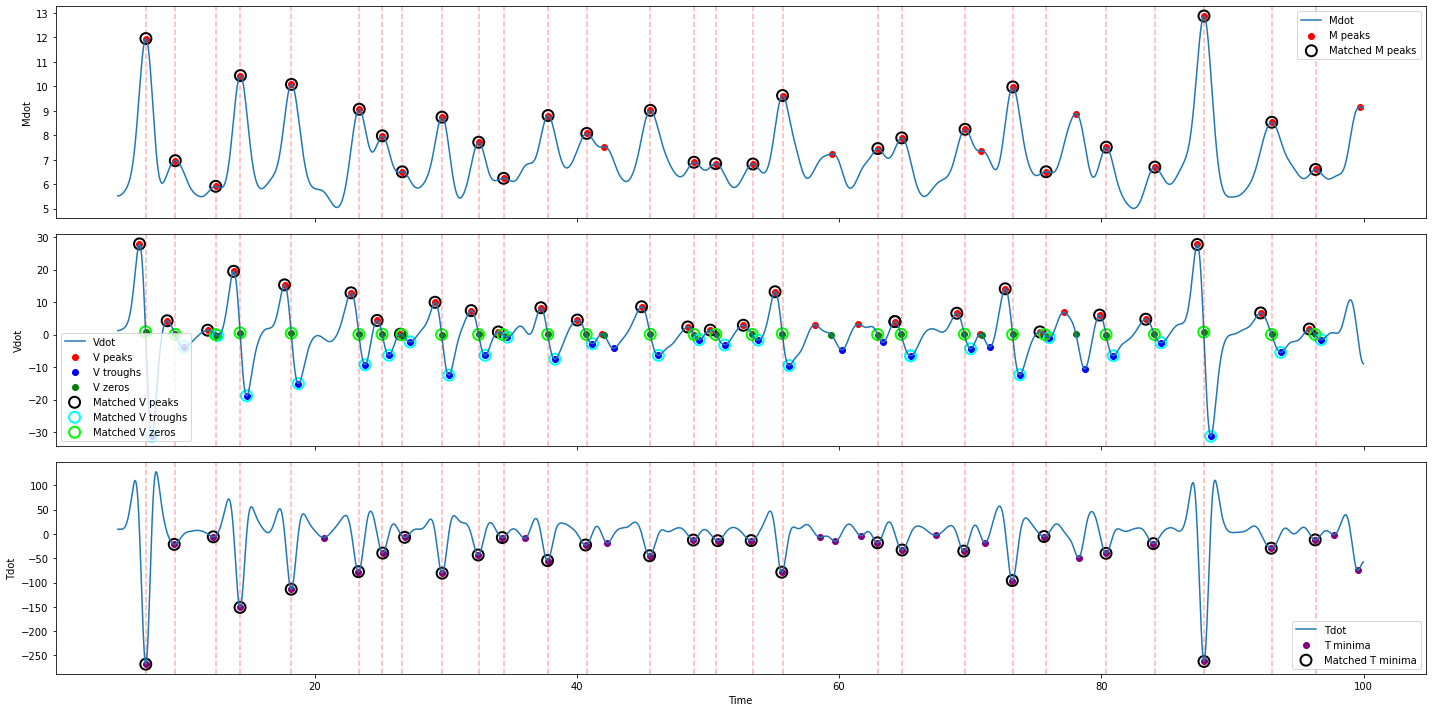

In [65]:
tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times, M_vals, T_vals, V_max_vals, V_min_vals, dt_M_T, dt_M_V0, dt_Vpk_Vtr, waiting_times = detect_events(Mdot[1, :9950], Vdot[1, :9950], Sdot[1, :9950], skip, 100, t_lag, n_individuals)

plot_events(tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times)

In [58]:
Plot_Moment_dynamics_simple( n_individuals, indices[:9950], Mdot[0, :9950], Vdot[0, :9950], Sdot[0, :9950], REPORTS_DIR, ex_name, figsize=(25, 15), dpi=600)

In [ ]:
results = detect_events_ensemble(Mdot, Vdot, Sdot, skip, tmax, t_lag, n_individuals)

tarray = results[0]

M_s_all = results[1]        # list of arrays (len = n_ens)
V_s_all = results[2]
T_s_all = results[3]

M_peaks_all = results[4]
V_peaks_all = results[5]
V_zeros_all = results[6]
V_troughs_all = results[7]
T_peaks_all = results[8]

event_M_idx_all  = results[9]
event_T_idx_all  = results[10]
event_V0_idx_all = results[11]
event_Vpk_idx_all = results[12]
event_Vtr_idx_all = results[13]

event_times_all = results[14]

M_vals_all = results[15]
T_vals_all = results[16]
V_max_vals_all = results[17]
V_min_vals_all = results[18]

dt_M_T_all = results[19]
dt_M_V0_all = results[20]
dt_Vpk_Vtr_all = results[21]

waiting_times_all = results[22]

all_waiting = np.concatenate([w for w in waiting_times_all if len(w) > 0])
all_dt_Vpk_Vtr = np.concatenate([dt for dt in dt_Vpk_Vtr_all if len(dt) > 0])

deltamu0 = 1/(1*all_dt_Vpk_Vtr)*np.log(7+4*np.sqrt(3))

In [60]:
np.mean(all_waiting)

3.5108879891289275

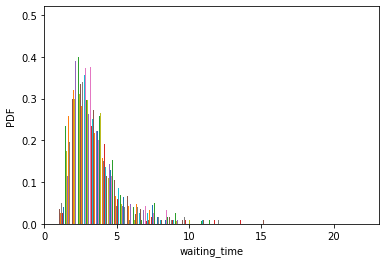

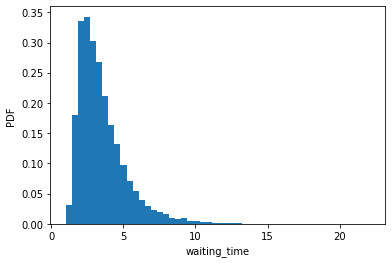

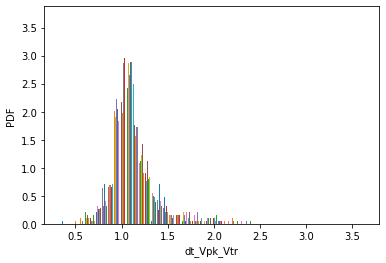

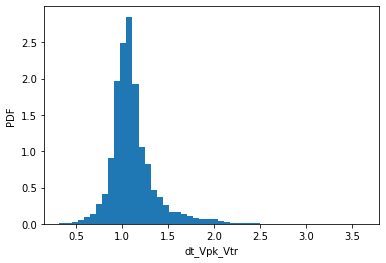

In [45]:
plt.hist(waiting_times_all, bins=50, density=True)
plt.ylabel("PDF ")
plt.xlabel("waiting_time")
plt.show()

plt.hist(all_waiting, bins=50, density=True)
plt.ylabel("PDF ")
plt.xlabel("waiting_time")
plt.show()

plt.hist(dt_Vpk_Vtr_all, bins=50, density=True)
plt.ylabel("PDF ")
plt.xlabel("dt_Vpk_Vtr")
plt.show()

plt.hist(all_dt_Vpk_Vtr, bins=50, density=True)
plt.ylabel("PDF ")
plt.xlabel("dt_Vpk_Vtr")
plt.show()


In [62]:
np.mean(deltamu0)**2*2.7/3.5

4.677551197859714

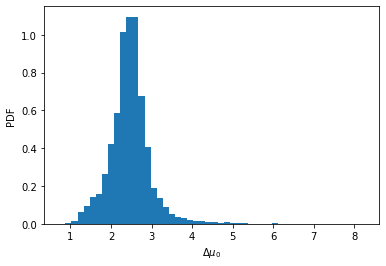

In [ ]:
plt.hist(deltamu0, bins=50, density=True)
plt.ylabel("PDF ")
plt.xlabel(r"$\Delta\mu_0$")
plt.show()

In [ ]:

print(np.mean(all_waiting))

3.5108879891289275


In [ ]:
n_individuals = 20000
b1_rate = 0.4
d1_rate = 0.6
skip = 5
tmax = 1000
t_lag = 200
n_ensemble = 128
indices = np.arange(skip*n_individuals, tmax*n_individuals, t_lag) 
n_out = len(indices) 
trait_values = np.zeros(n_individuals)
ex_name = f"b1_{b1_rate}_d1_{d1_rate}_N_{n_individuals}_tmax_{tmax}_skip_{skip}_lag_{t_lag}_righthump_8.5"
os.makedirs(os.path.join(FIGURES_DIR, ex_name), exist_ok=True)

In [25]:
n_individuals = 20000
b1_rate = 0.4
d1_rate = 0.6
skip = 5
tmax = 110
t_lag = 200
indices = np.arange(skip*n_individuals, tmax*n_individuals, t_lag) 
n_out = len(indices) 
trait_values = np.zeros(n_individuals)
ex_name = f"b1_{b1_rate}_d1_{d1_rate}_N_{n_individuals}_tmax_{tmax}_skip_{skip}_lag_{t_lag}_righthump_8.5"
os.makedirs(os.path.join(FIGURES_DIR, ex_name), exist_ok=True)

In [ ]:


Main_3D, Moments = methods.Quad_Sim_V00(b1_rate, 0, d1_rate, 0, tmax, indices, trait_values)
skwl = Main_3D[1, :]
stdl = Main_3D[2, :]
mean_trait_values = Main_3D[0, :]
Mdot = np.gradient(mean_trait_values, 1) * n_individuals / (t_lag)
Vdot = np.gradient(stdl**2, 1) * n_individuals / (t_lag)
Sdot = np.gradient(Moments[:], 1) * n_individuals / (t_lag) 

In [26]:
# np.savez(os.path.join(FIGURES_DIR, ex_name, "data.npz"), Mdot=Mdot, Vdot=Vdot, Sdot=Sdot)

X = np.load(os.path.join(FIGURES_DIR, ex_name, "data.npz"))
Mdot = X["Mdot"]; Vdot = X["Vdot"]; Sdot = X["Sdot"]

In [ ]:
n_individuals = 20000
b1_rate = 0.4
d1_rate = 0.6
skip = 5
tmax = 1000
t_lag = 200
indices = np.arange(skip*n_individuals, tmax*n_individuals, t_lag) 
n_out = len(indices) 
trait_values = np.zeros(n_individuals)
ex_name = f"b1_{b1_rate}_d1_{d1_rate}_N_{n_individuals}_tmax_{tmax}_skip_{skip}_lag_{t_lag}_righthump_8.5"

Main_3D, Moments = methods.Quad_Sim_V00(b1_rate, 0, d1_rate, 0, tmax, indices, trait_values)
skwl = Main_3D[1, :]
stdl = Main_3D[2, :]
mean_trait_values = Main_3D[0, :]
Mdot = np.gradient(mean_trait_values, 1) * n_individuals / (t_lag)
Vdot = np.gradient(stdl**2, 1) * n_individuals / (t_lag)
Sdot = np.gradient(Moments[:], 1) * n_individuals / (t_lag) 



In [27]:
tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times, M_vals, T_vals, V_max_vals, V_min_vals, dt_M_T, dt_M_V0, dt_Vpk_Vtr, waiting_times = detect_events(Mdot, Vdot, Sdot, skip, tmax, t_lag, n_individuals)


Number of events: 27
Mean waiting time: 3.760


In [28]:
np.mean(waiting_times), np.mean(M_vals), np.mean(T_vals), np.mean(V_max_vals), np.mean(V_min_vals), np.mean(dt_M_T), np.mean(dt_M_V0), np.mean(dt_Vpk_Vtr)

(3.7603846153846154,
 8.71026295442285,
 -66.98892886023457,
 8.648160360130747,
 -9.732192799065635,
 0.00037037037036996773,
 -0.022592592592592244,
 1.1274074074074067)

Number of events: 27
Mean waiting time: 3.760


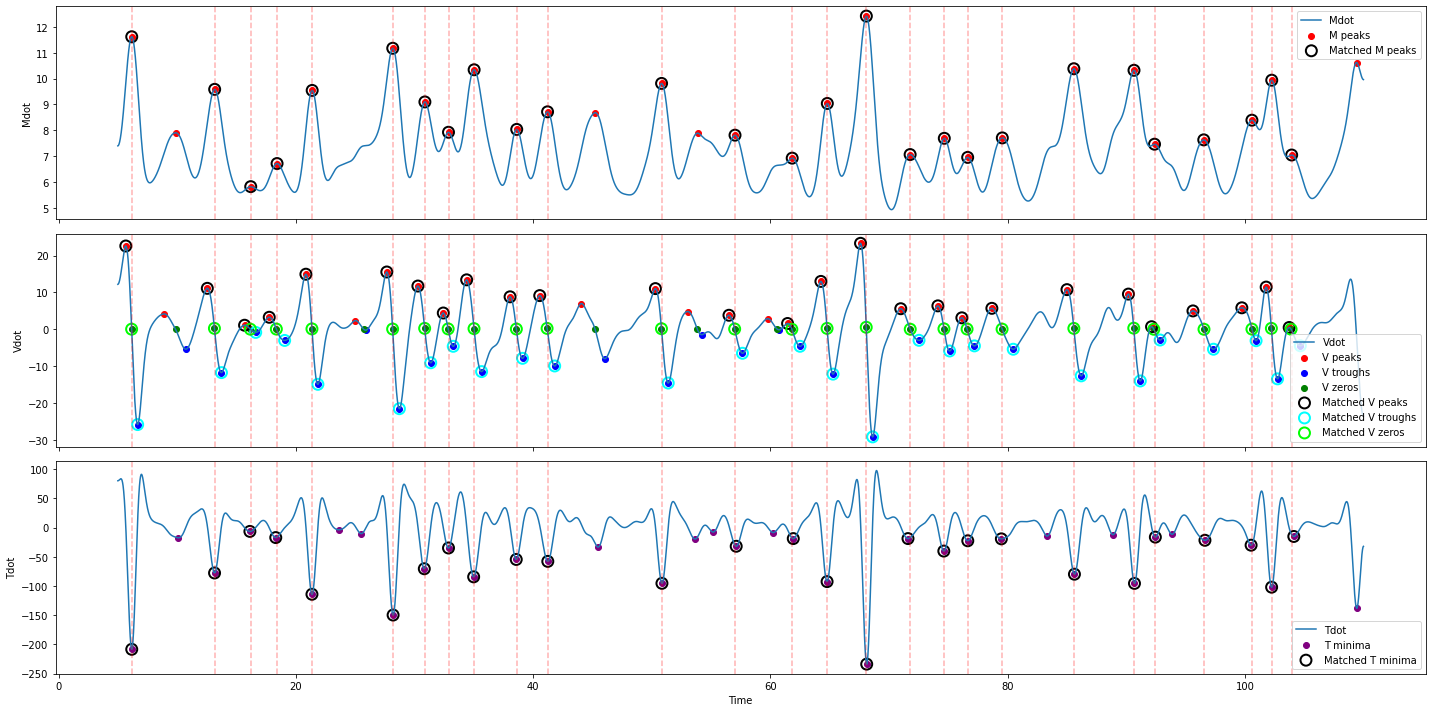

In [21]:
tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times, M_vals, T_vals, V_max_vals, V_min_vals, dt_M_T, dt_M_V0, dt_Vpk_Vtr, waiting_times = detect_events(Mdot, Vdot, Sdot, skip, tmax, t_lag, n_individuals)

plot_events(tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times)

Number of events: 18
Mean waiting time: 5.652


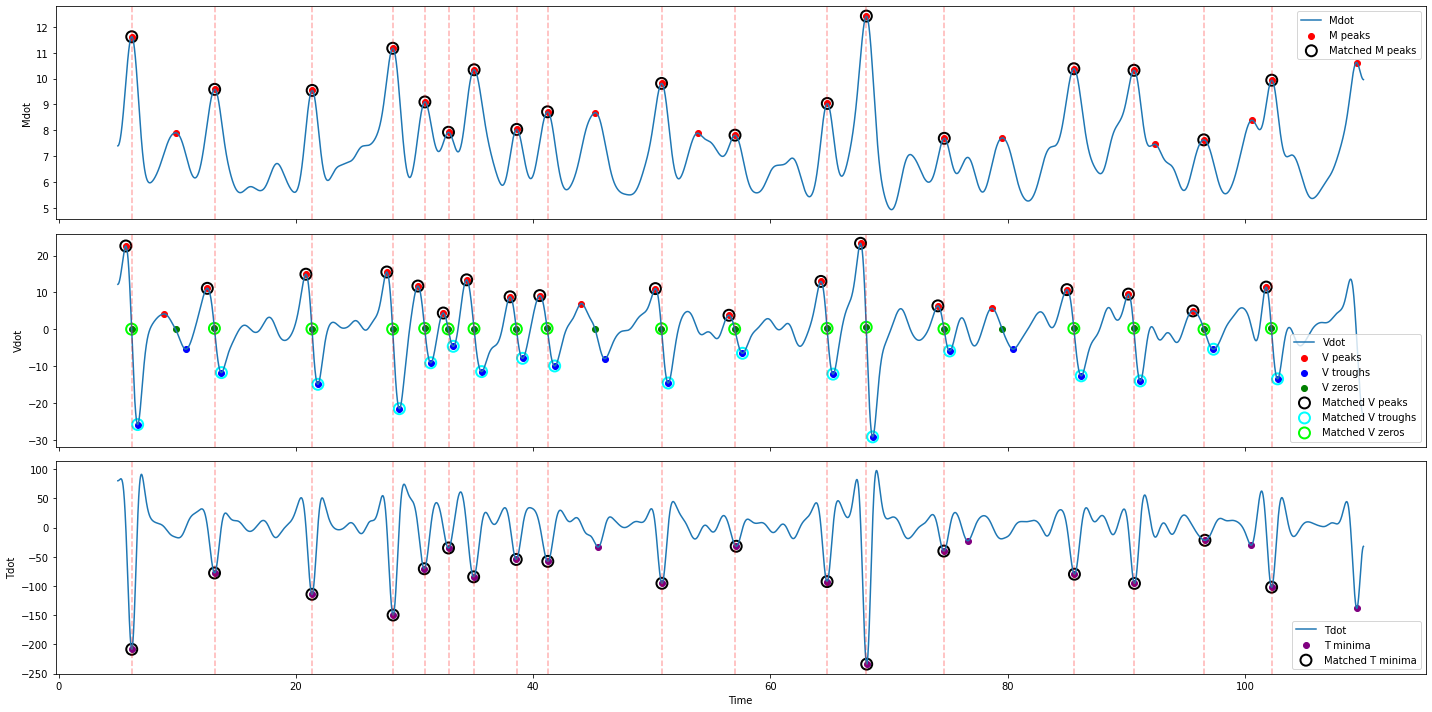

In [19]:
tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times, M_vals, T_vals, V_max_vals, V_min_vals, dt_M_T, dt_M_V0, dt_Vpk_Vtr, waiting_times = detect_events(Mdot, Vdot, Sdot, skip, tmax, t_lag, n_individuals)

plot_events(tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times)

Number of events: 10
Mean waiting time: 4.764


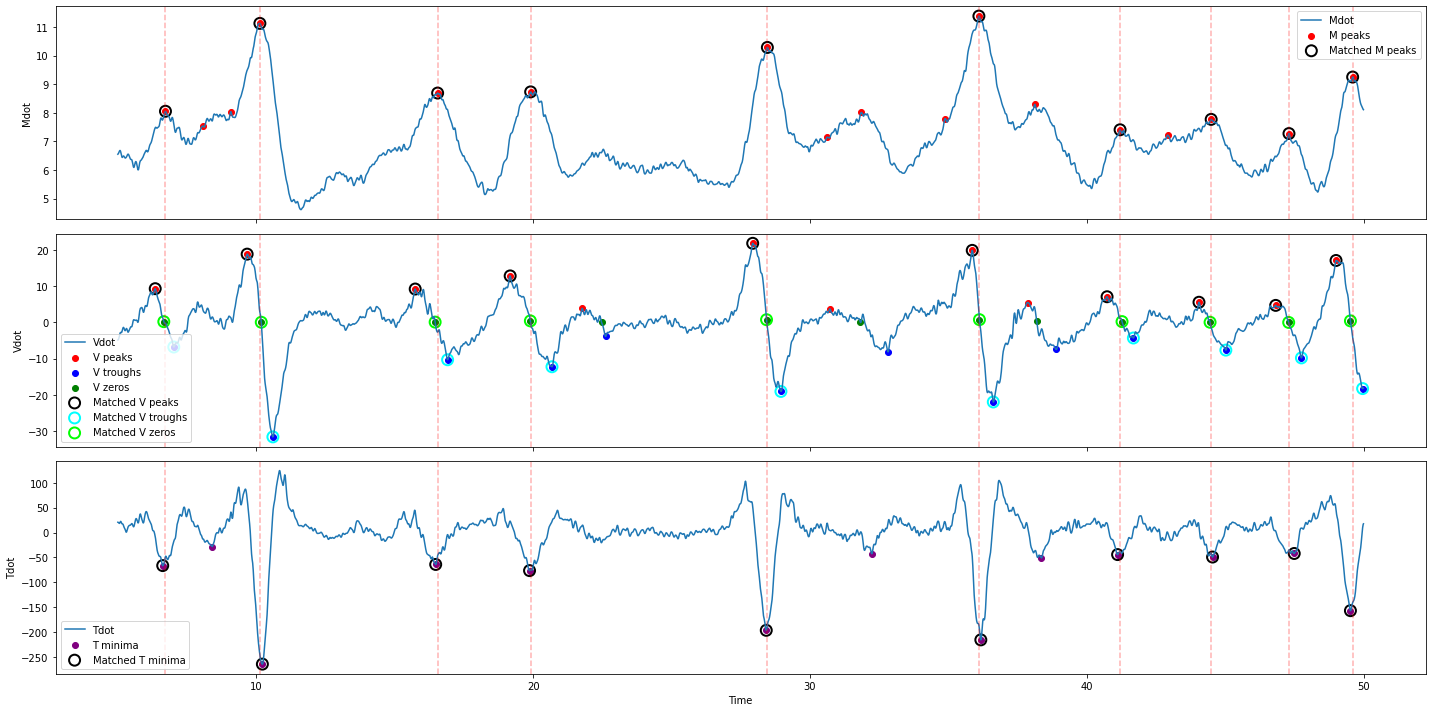

In [18]:
tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times, M_vals, T_vals, V_max_vals, V_min_vals, dt_M_T, dt_M_V0, dt_Vpk_Vtr, waiting_times = detect_events(Mdot, Vdot, Sdot, skip, 50, t_lag, n_individuals)

plot_events(tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times)

Number of events: 174
Mean waiting time: 5.687


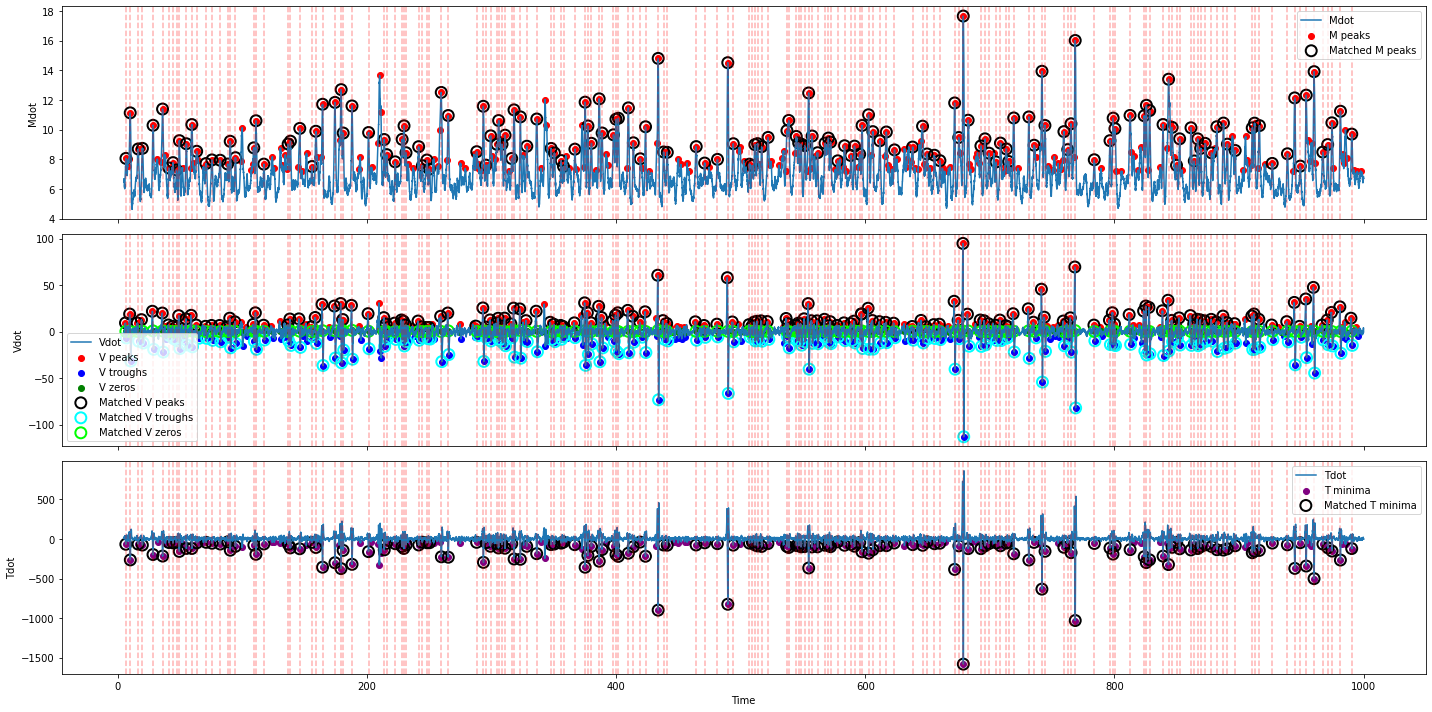

In [12]:
tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times, M_vals, T_vals, V_max_vals, V_min_vals, dt_M_T, dt_M_V0, dt_Vpk_Vtr, waiting_times = detect_events(Mdot, Vdot, Sdot, skip, tmax, t_lag, n_individuals)

plot_events(tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times)

Number of events: 23
Mean waiting time: 4.037


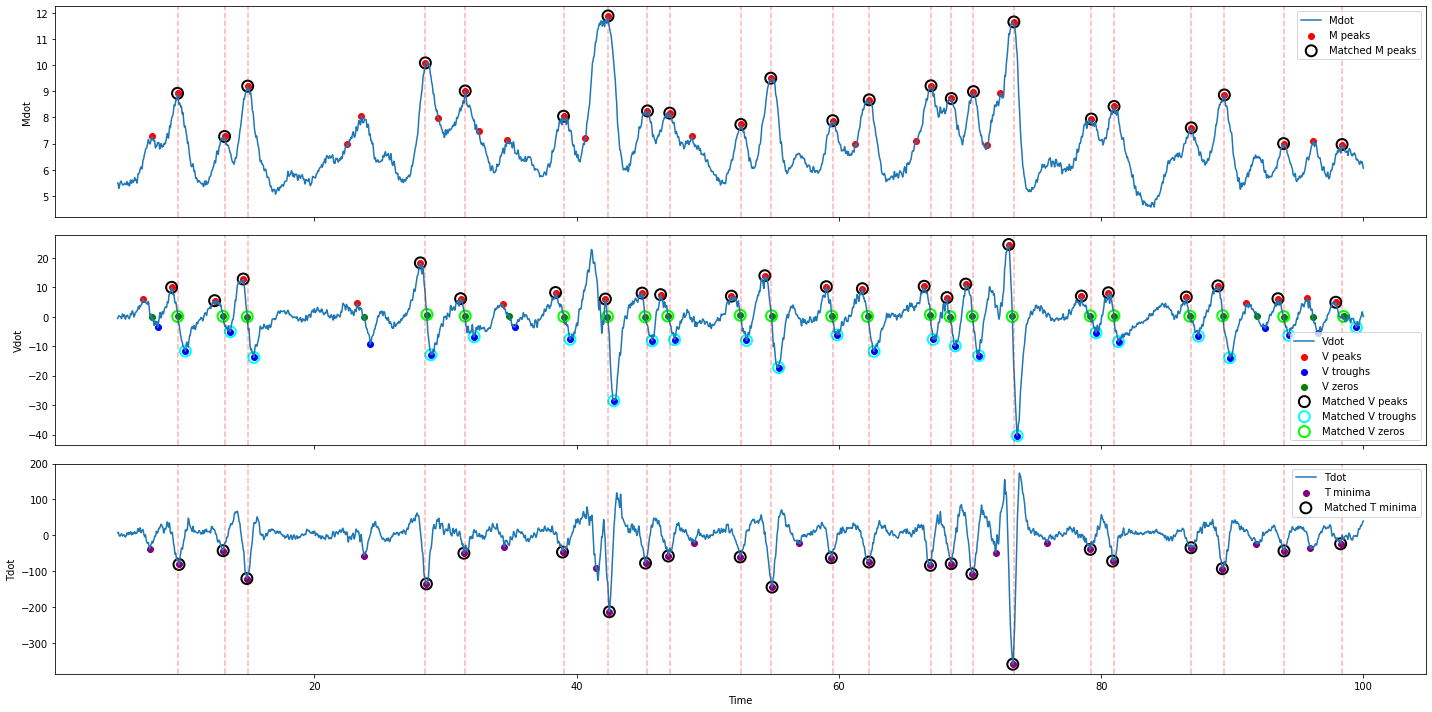

In [9]:
tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times, M_vals, T_vals, V_max_vals, V_min_vals, dt_M_T, dt_M_V0, dt_Vpk_Vtr, waiting_times = detect_events(Mdot, Vdot, Sdot, skip, tmax, t_lag, n_individuals)

plot_events(tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times)

Number of events: 190
Mean waiting time: 5.244


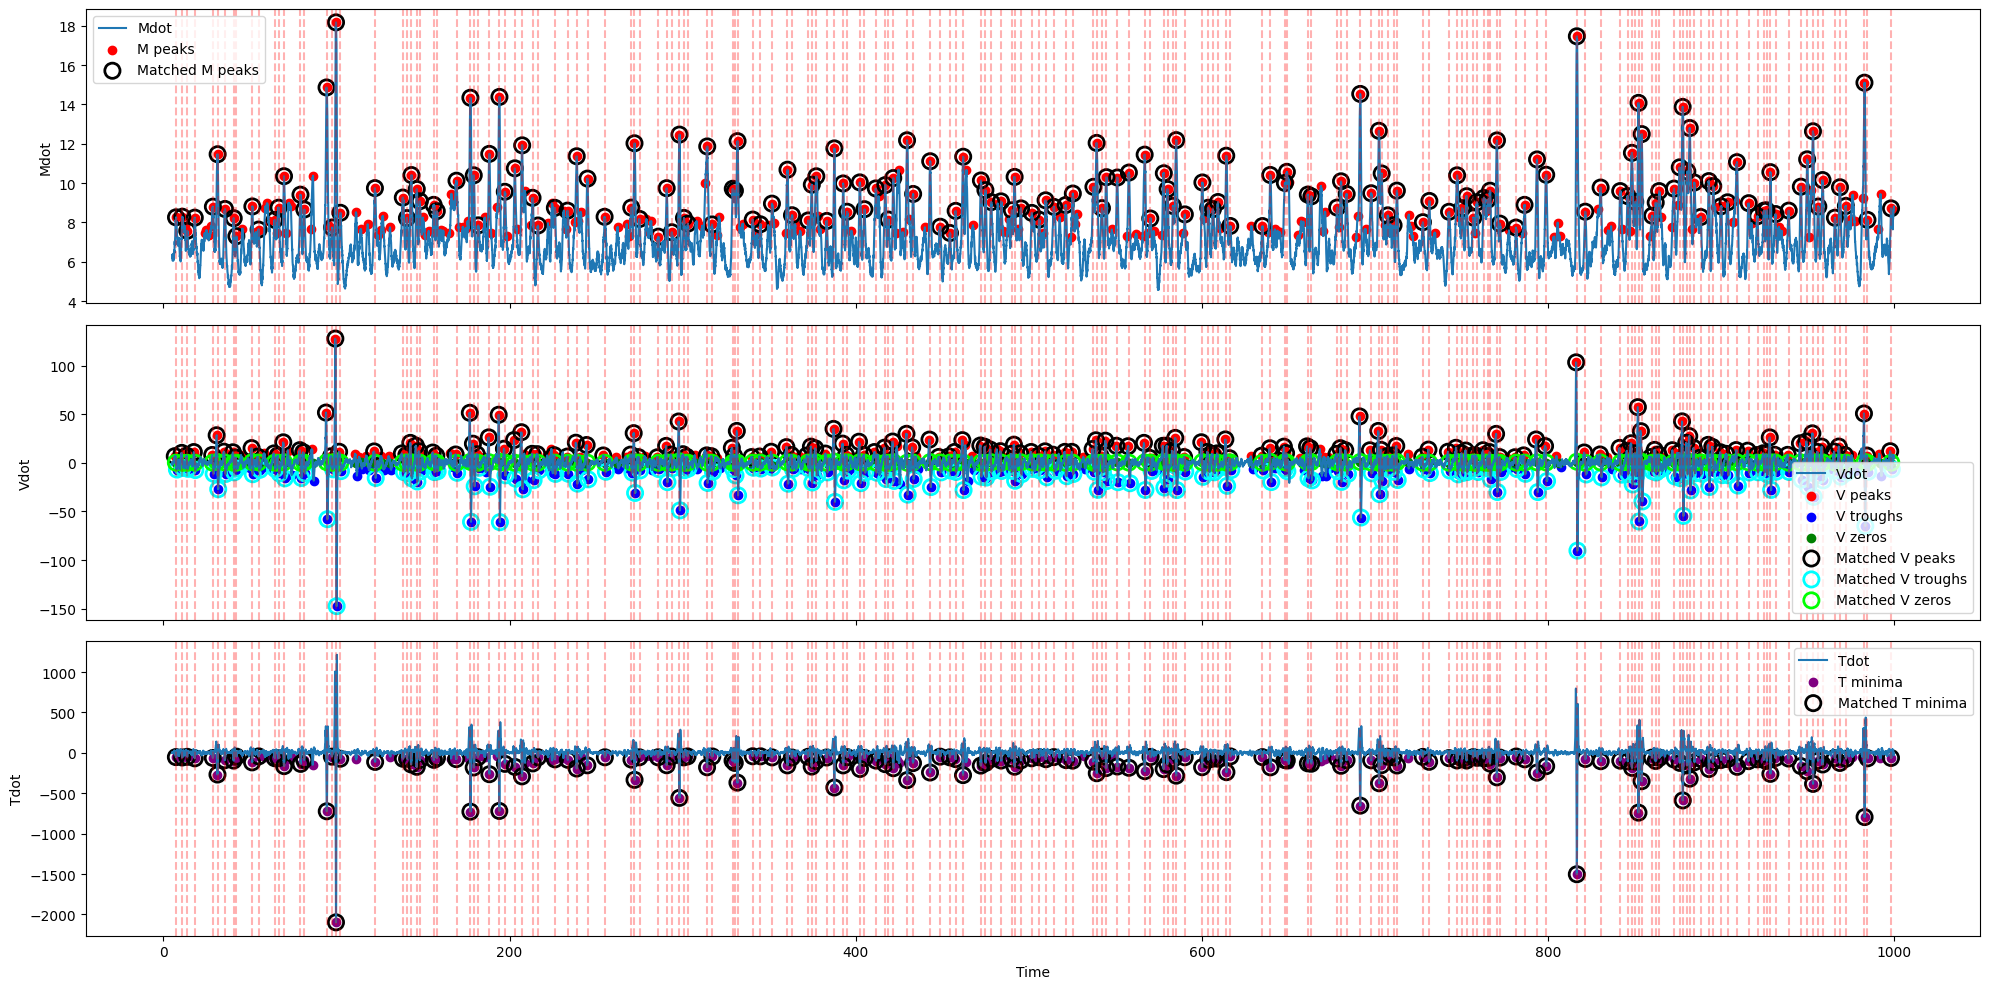

In [51]:
tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times, M_vals, T_vals, V_max_vals, V_min_vals, dt_M_T, dt_M_V0, dt_Vpk_Vtr, waiting_times = detect_events(Mdot, Vdot, Sdot, skip, tmax, t_lag, n_individuals)

plot_events(tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times)

Number of events: 22
Mean waiting time: 3.792


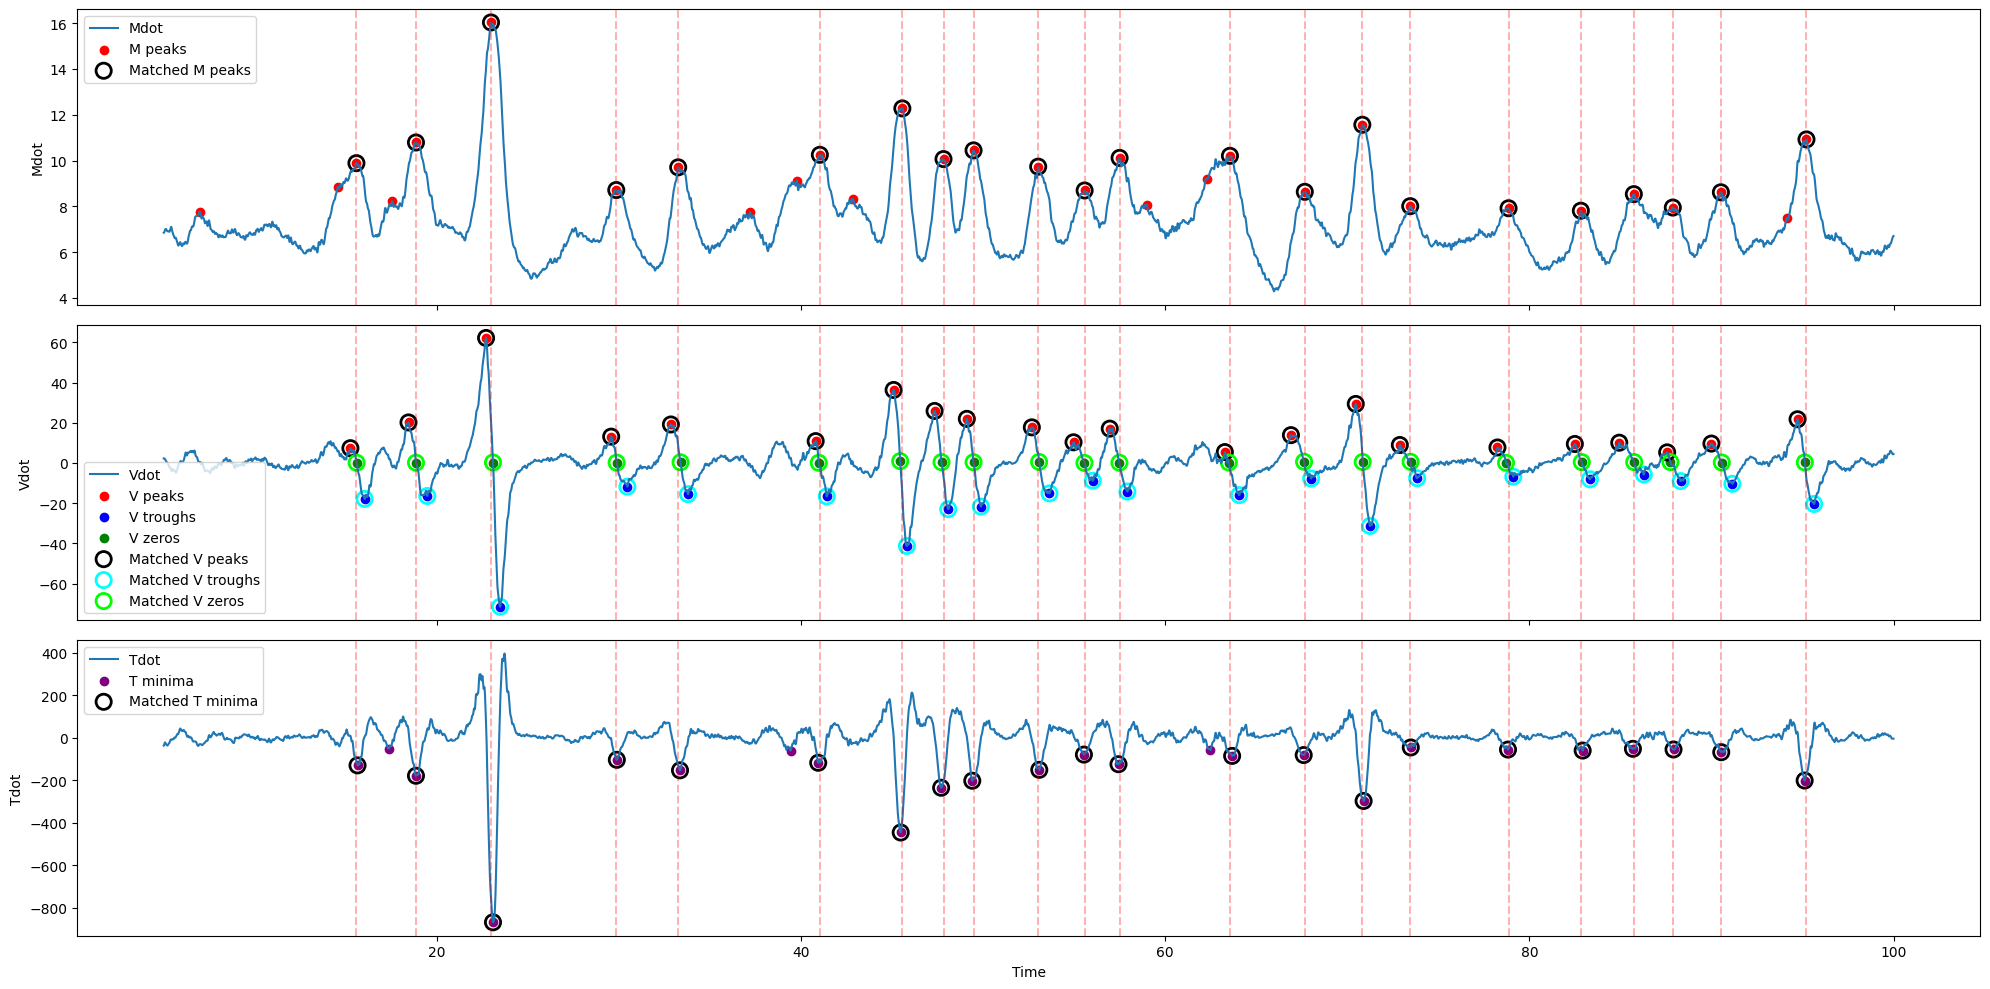

In [47]:
tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times, M_vals, T_vals, V_max_vals, V_min_vals, dt_M_T, dt_M_V0, dt_Vpk_Vtr, waiting_times = detect_events(Mdot, Vdot, Sdot, skip, tmax, t_lag, n_individuals)

plot_events(tarray, M_s, V_s, T_s, M_peaks, V_peaks, V_zeros, V_troughs, T_peaks, event_M_idx, event_T_idx, event_V0_idx, event_Vpk_idx, event_Vtr_idx, event_times)

In [52]:
np.mean(waiting_times), np.mean(M_vals), np.mean(T_vals), np.mean(V_max_vals), np.mean(V_min_vals), np.mean(dt_M_T), np.mean(dt_M_V0), np.mean(dt_Vpk_Vtr)

(np.float64(5.243809523809524),
 np.float64(9.710908172323663),
 np.float64(-162.06907335176246),
 np.float64(16.01519292932703),
 np.float64(-16.80039410915216),
 np.float64(-0.010842105263159357),
 np.float64(-0.022421052631578498),
 np.float64(0.9277894736842074))

In [38]:
np.mean(waiting_times), np.mean(M_vals), np.mean(T_vals), np.mean(V_max_vals), np.mean(V_min_vals), np.mean(dt_M_T), np.mean(dt_M_V0), np.mean(dt_Vpk_Vtr)

(np.float64(9.524230769230769),
 np.float64(9.694514149788704),
 np.float64(-168.1062197505078),
 np.float64(17.506834747116493),
 np.float64(-18.165169731900946),
 np.float64(-0.008612440191386067),
 np.float64(-0.026889952153108243),
 np.float64(0.9624880382775102))

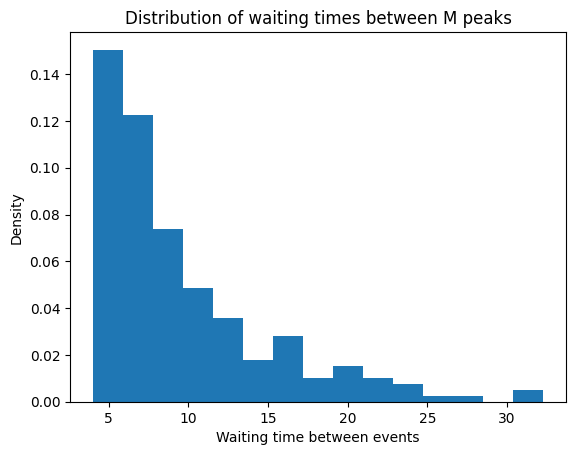

In [36]:
plt.hist(waiting_times, bins=15, density=True)
plt.xlabel("Waiting time between events")
plt.ylabel("Density")
plt.title("Distribution of waiting times between M peaks")
plt.show()